<a href="https://colab.research.google.com/github/zizimostafa/mnist-mlp-nn_project/blob/main/NN_ASSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.82MB/s]


In [ ]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

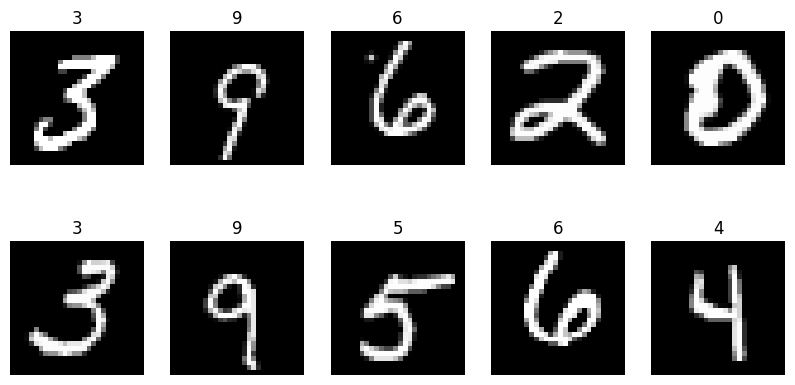

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(labels[i].item())
    plt.axis('off')

plt.show()

In [ ]:
class MLP(nn.Module):

    def __init__(self):

        super(MLP, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(28*28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = x.view(-1, 28*28)

        return self.model(x)

In [ ]:
model = MLP()

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
train_losses = []

epochs = 10

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.view(-1, 28*28)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 0.2827
Epoch [2/10] Loss: 0.1142
Epoch [3/10] Loss: 0.0771
Epoch [4/10] Loss: 0.0588
Epoch [5/10] Loss: 0.0468
Epoch [6/10] Loss: 0.0366
Epoch [7/10] Loss: 0.0304
Epoch [8/10] Loss: 0.0246
Epoch [9/10] Loss: 0.0227
Epoch [10/10] Loss: 0.0188


In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(-1, 28*28)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 97.85


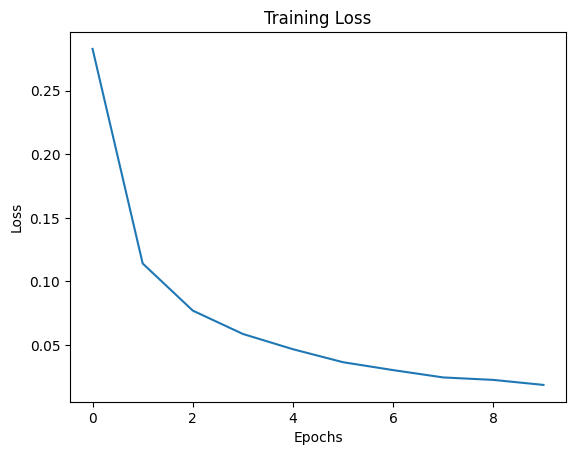

In [ ]:
plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

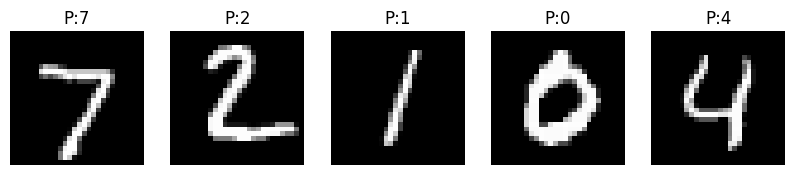

In [ ]:
images, labels = next(iter(test_loader))

outputs = model(images.view(-1, 28*28))

_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(f"P:{predicted[i].item()}")

    plt.axis('off')

plt.show()

In [ ]:
# Tanh Experiment

class MLP_Tanh(nn.Module):

    def __init__(self):

        super(MLP_Tanh, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(28*28, 128),
            nn.Tanh(),

            nn.Linear(128, 64),
            nn.Tanh(),

            nn.Linear(64, 10)
        )

    def forward(self, x):

        x = x.view(-1, 28*28)

        return self.model(x)

model_tanh = MLP_Tanh()

criterion = nn.CrossEntropyLoss()

optimizer_tanh = optim.Adam(
    model_tanh.parameters(),
    lr=0.001
)

train_losses_tanh = []

epochs = 10

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.view(-1, 28*28)

        outputs = model_tanh(images)

        loss = criterion(outputs, labels)

        optimizer_tanh.zero_grad()

        loss.backward()

        optimizer_tanh.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses_tanh.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(-1, 28*28)

        outputs = model_tanh(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy_tanh = 100 * correct / total

print("Tanh Accuracy:", accuracy_tanh)

Epoch [1/10] Loss: 0.2849
Epoch [2/10] Loss: 0.1213
Epoch [3/10] Loss: 0.0804
Epoch [4/10] Loss: 0.0582
Epoch [5/10] Loss: 0.0429
Epoch [6/10] Loss: 0.0335
Epoch [7/10] Loss: 0.0278
Epoch [8/10] Loss: 0.0213
Epoch [9/10] Loss: 0.0191
Epoch [10/10] Loss: 0.0151
Tanh Accuracy: 97.5


In [ ]:
print("\nFinal Comparison")

print(f"ReLU Accuracy: {accuracy:.2f}%")
print(f"Tanh Accuracy: {accuracy_tanh:.2f}%")


Final Comparison
ReLU Accuracy: 97.85%
Tanh Accuracy: 97.50%
